## Punzi figure of merit

accuracy treats all misclassifications equally which is wrong for a discovery experiment. the Punzi FOM (Punzi 2003) replaces accuracy with a metric that directly measures discovery sensitivity, connecting the BDT selection to the question of how long we need to run.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import pickle
import os

os.makedirs('../plots', exist_ok=True)

In [2]:
features = ['PT1', 'PT2', 'P1', 'P2', 'TotalPT', 'VertexChisq', 'Isolation', 'MASS']

#load data
signal     = pd.read_csv('../data/signal_Bs2MuMu.txt',         sep=r'\s+', header=None, names=features)
background = pd.read_csv('../data/background_combinatorial.txt', sep=r'\s+', header=None, names=features)
signal     = signal.apply(pd.to_numeric, errors='coerce').dropna().reset_index(drop=True)
background = background.apply(pd.to_numeric, errors='coerce').dropna().reset_index(drop=True)

#load the trained 7-feature BDT from bdt.ipynb
features7 = [f for f in features if f != 'MASS']
with open('../bdt_model.pkl', 'rb') as fh:
    bdt7 = pickle.load(fh)

#load the hard-cut efficiencies for comparison
with open('../bdt_results.json') as fh:
    bdt_results = json.load(fh)

print('loaded BDT model and results')
print(f"hard-cut signal efficiency:     {bdt_results['signal_efficiency']:.4f}")
print(f"hard-cut background efficiency: {bdt_results['background_efficiency']:.4f}")

loaded BDT model and results
hard-cut signal efficiency:     0.9305
hard-cut background efficiency: 0.0726


In [3]:
#get continuous BDT output scores
bdt_scores_sig = bdt7.predict_proba(signal[features7])[:, 1]
bdt_scores_bkg = bdt7.predict_proba(background[features7])[:, 1]

N_BKG_YEAR = 2000
n_sigma     = 5.0

#scan thresholds
thresholds   = np.linspace(0.01, 0.99, 300)
fom_vals     = []
acc_vals_t   = []
sig_eff_scan = []
bkg_eff_scan = []

#floor on background efficiency: we only have 10k MC events so can't measure below 1/10k
bkg_eff_floor = 1.0 / len(background)

for t in thresholds:
    eps_s = (bdt_scores_sig >= t).mean()
    eps_b = max((bdt_scores_bkg >= t).mean(), bkg_eff_floor)
    B     = N_BKG_YEAR * eps_b
    fom   = eps_s / (n_sigma / 2.0 + np.sqrt(B))
    acc   = ((bdt_scores_sig >= t).sum() + (bdt_scores_bkg < t).sum()) / (len(bdt_scores_sig) + len(bdt_scores_bkg))
    fom_vals.append(fom)
    acc_vals_t.append(acc)
    sig_eff_scan.append(eps_s)
    bkg_eff_scan.append(eps_b)

fom_vals     = np.array(fom_vals)
acc_vals_t   = np.array(acc_vals_t)
sig_eff_scan = np.array(sig_eff_scan)
bkg_eff_scan = np.array(bkg_eff_scan)

i_fom = np.argmax(fom_vals)
i_acc = np.argmax(acc_vals_t)

sig_eff_punzi = sig_eff_scan[i_fom]
bkg_eff_punzi = bkg_eff_scan[i_fom]

print(f'Punzi-optimal threshold:    {thresholds[i_fom]:.3f}')
print(f'  signal efficiency:         {sig_eff_punzi:.4f}')
print(f'  background efficiency:     {bkg_eff_punzi:.4f}')
print()
print(f'Accuracy-optimal threshold: {thresholds[i_acc]:.3f}')
print(f'  signal efficiency:         {sig_eff_scan[i_acc]:.4f}')
print(f'  background efficiency:     {bkg_eff_scan[i_acc]:.4f}')

Punzi-optimal threshold:    0.626
  signal efficiency:         0.5903
  background efficiency:     0.0072

Accuracy-optimal threshold: 0.479
  signal efficiency:         0.9619
  background efficiency:     0.0964


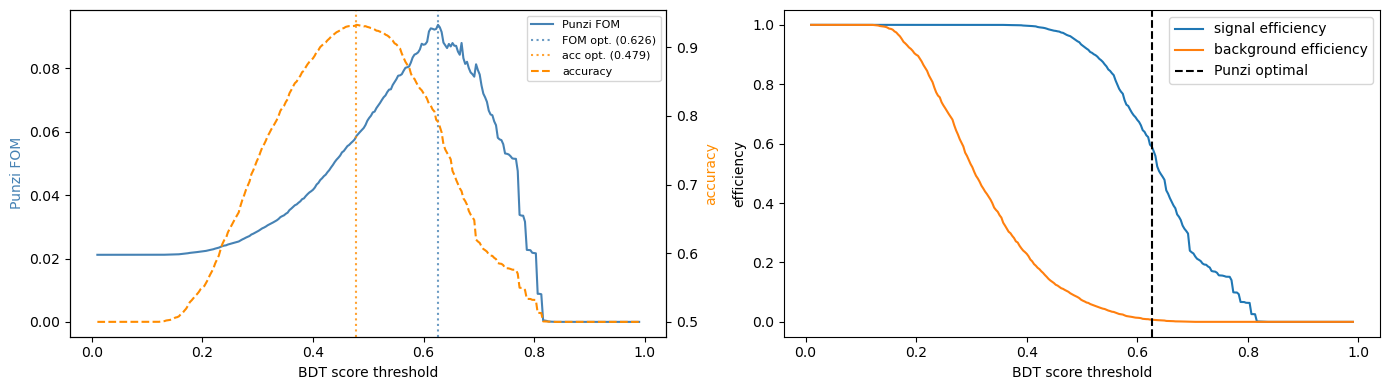

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

#left: FOM and accuracy as a function of BDT threshold
ax  = axes[0]
ax2 = ax.twinx()
ax.plot(thresholds, fom_vals,    color='steelblue',  label='Punzi FOM')
ax2.plot(thresholds, acc_vals_t, color='darkorange', linestyle='--', label='accuracy')
ax.axvline(thresholds[i_fom], color='steelblue',  linestyle=':', alpha=0.8, label=f'FOM opt. ({thresholds[i_fom]:.3f})')
ax.axvline(thresholds[i_acc], color='darkorange', linestyle=':', alpha=0.8, label=f'acc opt. ({thresholds[i_acc]:.3f})')
ax.set_xlabel('BDT score threshold')
ax.set_ylabel('Punzi FOM', color='steelblue')
ax2.set_ylabel('accuracy', color='darkorange')
lines  = ax.get_legend_handles_labels()[0]  + ax2.get_legend_handles_labels()[0]
labels = ax.get_legend_handles_labels()[1]  + ax2.get_legend_handles_labels()[1]
ax.legend(lines, labels, fontsize=8)

#right: signal and background efficiency vs threshold
ax = axes[1]
ax.plot(thresholds, sig_eff_scan, label='signal efficiency')
ax.plot(thresholds, bkg_eff_scan, label='background efficiency')
ax.axvline(thresholds[i_fom], linestyle='--', color='black', label='Punzi optimal')
ax.set_xlabel('BDT score threshold')
ax.set_ylabel('efficiency')
ax.legend()

plt.tight_layout()
plt.savefig('../plots/punzi_fom.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
#compare sensitivity S/sqrt(B) at both working points
#significance scales as sqrt(T) * S/sqrt(B), so required duration scales as 1/(S/sqrt(B))^2
sens_punzi = (50 * sig_eff_punzi)          / np.sqrt(N_BKG_YEAR * bkg_eff_punzi)
sens_acc   = (50 * sig_eff_scan[i_acc])    / np.sqrt(N_BKG_YEAR * bkg_eff_scan[i_acc])

print(f'S/sqrt(B) at Punzi threshold:    {sens_punzi:.4f}')
print(f'S/sqrt(B) at accuracy threshold: {sens_acc:.4f}')
print(f'Punzi working point is {sens_punzi/sens_acc:.3f}x more sensitive per year')
print(f'=> requires {(sens_acc/sens_punzi)**2:.3f}x as long to run at the accuracy threshold')

#save Punzi-optimal efficiencies to bdt_results.json for use in mass_fit.ipynb
bdt_results['signal_efficiency_punzi']     = float(sig_eff_punzi)
bdt_results['background_efficiency_punzi'] = float(bkg_eff_punzi)
with open('../bdt_results.json', 'w') as fh:
    json.dump(bdt_results, fh, indent=2)
print('\nupdated bdt_results.json with Punzi-optimal efficiencies')

S/sqrt(B) at Punzi threshold:    7.7779
S/sqrt(B) at accuracy threshold: 3.4637
Punzi working point is 2.246x more sensitive per year
=> requires 0.198x as long to run at the accuracy threshold

updated bdt_results.json with Punzi-optimal efficiencies
